Simulating Data...
Building Weak-Form Matrices...
Running LASSO...


Recovered Variance Drift Coefs: [ 0.08218248 -2.0376142 ]
Recovered Leverage Coefs (a_12): [-0.         -0.20462275]


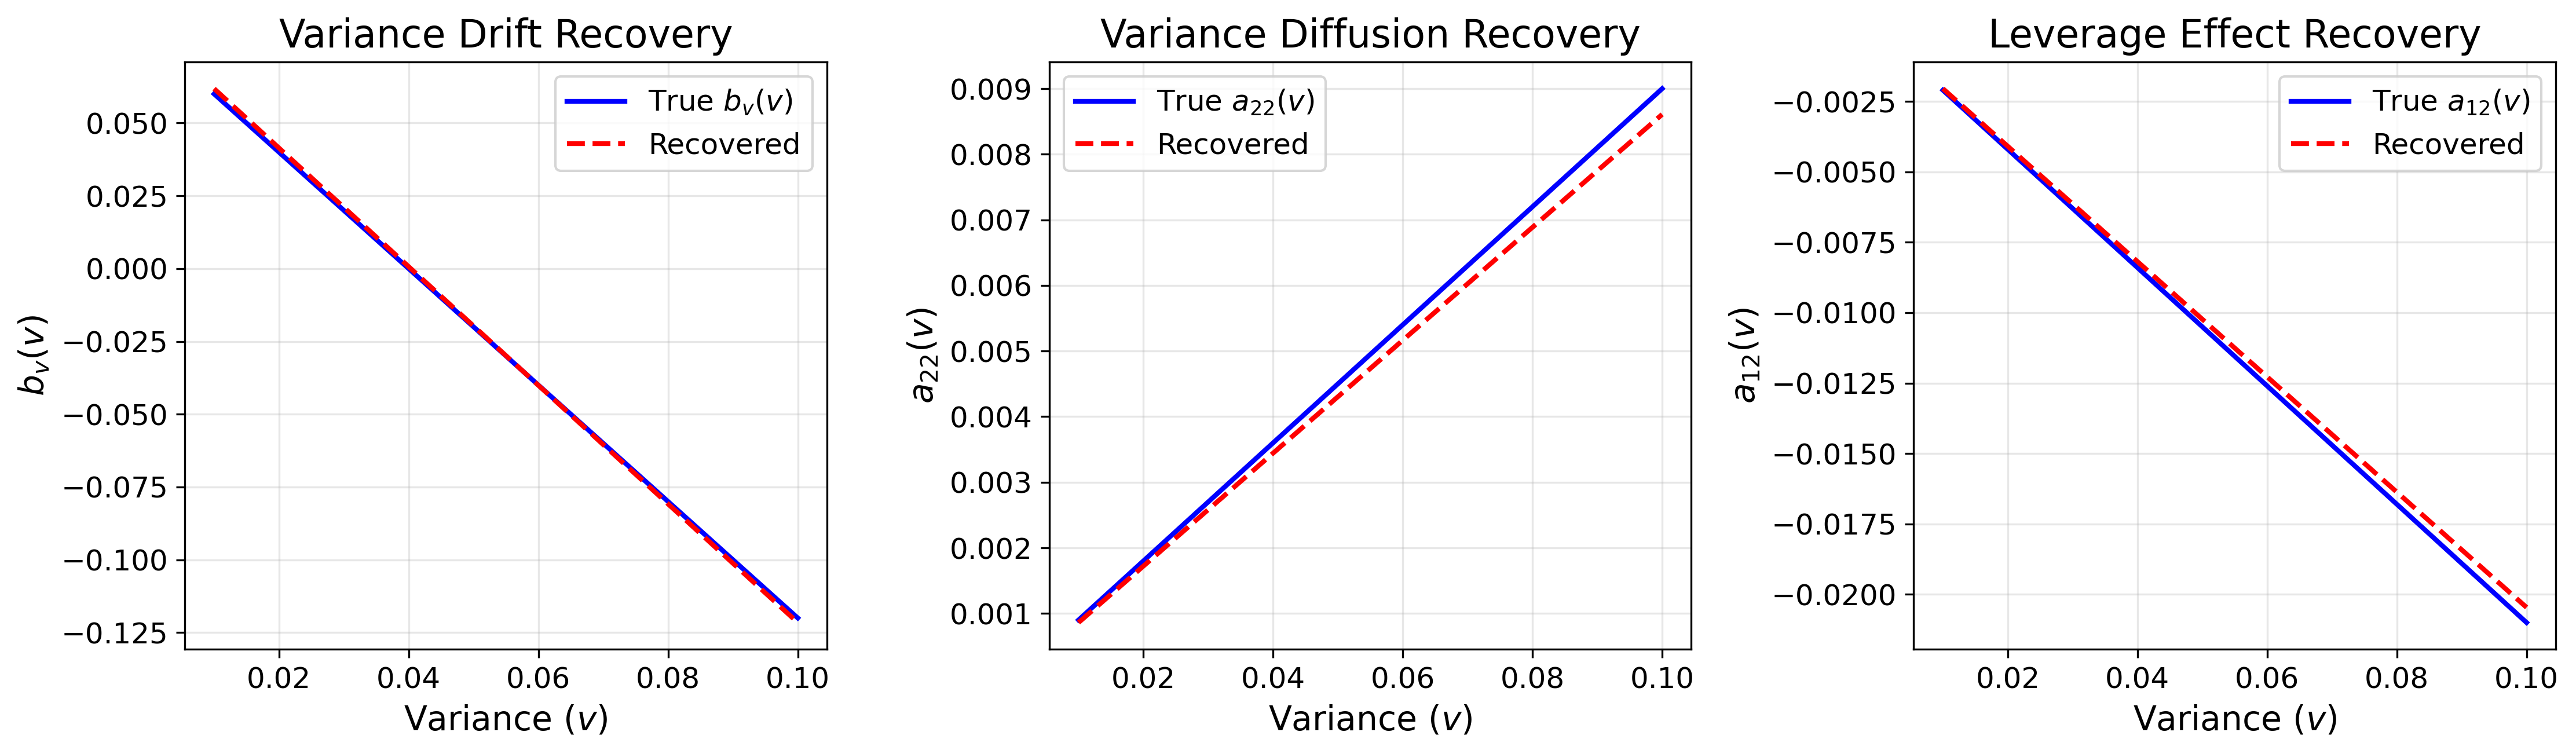

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Publication-Ready Plot Settings
# ==========================================
# These rcParams ensure figures match standard LaTeX document styling
plt.rcParams.update({
    "text.usetex": False, # Set to True if you have a local LaTeX distribution installed
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "savefig.bbox": "tight"
})

# ==========================================
# 2. Heston Data Generation & Proxy
# ==========================================
def simulate_heston_and_ohlc(T=100, dt_highfreq=0.0001, dt_macro=1.0/252.0):
    """
    Simulates high-frequency Heston dynamics and aggregates to daily OHLC.
    """
    np.random.seed(42)
    N_hf = int(T / dt_highfreq)
    N_macro = int(T / dt_macro)
    steps_per_day = int(dt_macro / dt_highfreq)

    # Heston Parameters
    mu, kappa, theta, xi, rho = 0.05, 2.0, 0.04, 0.3, -0.7

    x = np.zeros(N_hf)
    v = np.zeros(N_hf)
    v[0] = theta

    # Generate Correlated Brownian Motions
    dW_x = np.random.normal(0, np.sqrt(dt_highfreq), N_hf)
    dW_v_uncorr = np.random.normal(0, np.sqrt(dt_highfreq), N_hf)
    dW_v = rho * dW_x + np.sqrt(1 - rho**2) * dW_v_uncorr

    # Euler-Maruyama Simulation (High Frequency)
    for i in range(N_hf - 1):
        v_curr = max(v[i], 1e-5) # Feller boundary protection
        x[i+1] = x[i] + (mu - 0.5 * v_curr) * dt_highfreq + np.sqrt(v_curr) * dW_x[i]
        v[i+1] = v[i] + kappa * (theta - v_curr) * dt_highfreq + xi * np.sqrt(v_curr) * dW_v[i]

    # Aggregate to Macro (Daily) OHLC and compute Garman-Klass
    ohlc_x = np.zeros(N_macro)
    v_gk = np.zeros(N_macro)
    v_true_macro = np.zeros(N_macro)

    for i in range(N_macro):
        idx_start = i * steps_per_day
        idx_end = idx_start + steps_per_day
        path_segment = x[idx_start:idx_end]

        O, C = path_segment[0], path_segment[-1]
        H, L = np.max(path_segment), np.min(path_segment)

        # Garman-Klass Estimator (corrected for log-prices, annualized)
        gk = 0.5 * (H - L)**2 - (2*np.log(2) - 1) * (C - O)**2
        v_gk[i] = max(gk / dt_macro, 1e-6)
        # Anchor the macro price to the exact same timestamp as the macro variance
        ohlc_x[i] = O
        v_true_macro[i] = v[idx_start] # Anchor at the open

    return ohlc_x, v_gk, v_true_macro, dt_macro

# ==========================================
# 3. Weak-Form SINDy Core
# ==========================================
def build_weak_matrices(x, v_state, dt, M=50, bandwidth_factor=1.5):
    """
    Builds the design matrix A and response vectors B, Q using spatial kernels.
    Uses time-shifted alignment to prevent forward-looking bias.
    """
    N = len(x) - 1

    # Time-shifted alignment: Use v_{n-1} as the state for step n
    state = v_state[:-1]
    dx = np.diff(x)
    dv = np.diff(v_state)

    # Feature Library Theta(v) = [1, v]
    Theta = np.vstack([np.ones_like(state), state]).T
    K_features = Theta.shape[1]

    # Adaptive Spatial Kernels based on empirical quantiles
    centers = np.linspace(np.percentile(state, 5), np.percentile(state, 95), M)
    h = bandwidth_factor * np.std(state) / np.sqrt(M) # Simple localized heuristic

    A = np.zeros((M, K_features))
    B_v = np.zeros(M)
    Q_x = np.zeros(M)
    Q_v = np.zeros(M)
    Q_xv = np.zeros(M)

    for j, center in enumerate(centers):
        # Gaussian Kernel evaluation
        K_j = np.exp(-0.5 * ((state - center) / h)**2)

        # Matrix Construction (Eq. 11, 12, 13 from the paper)
        for k in range(K_features):
            A[j, k] = np.sum(K_j * Theta[:, k]) * dt

        B_v[j] = np.sum(K_j * dv)
        Q_x[j] = np.sum(K_j * dx**2)
        Q_v[j] = np.sum(K_j * dv**2)
        Q_xv[j] = np.sum(K_j * dx * dv) # Cross-variation for leverage

    return A, B_v, Q_x, Q_v, Q_xv, centers, Theta, state, h # ADDED 'h'

# ==========================================
# 4. Sparse Regression & Execution
# ==========================================
print("Simulating Data...")
x, v_gk, v_true, dt = simulate_heston_and_ohlc()

print("Building Weak-Form Matrices...")
# You can swap v_gk with v_true to test the proxy impact vs perfect information
A, B_v, Q_x, Q_v, Q_xv, centers, Theta, state, h = build_weak_matrices(x, v_true, dt) # UNPACK 'h' and use v_true

# Normalize A for LASSO
A_norms = np.linalg.norm(A, axis=0)
A_normalized = A / A_norms

print("Running LASSO...")
# 1. Drift Recovery (Variance process)
lasso_drift = LassoCV(cv=5, fit_intercept=False)
lasso_drift.fit(A_normalized, B_v)
c_hat = lasso_drift.coef_ / A_norms
b_hat_v = Theta @ c_hat

# 2. Bias-Corrected Diffusion Recovery (Variance)
# BUG FIX: Use the exact spatial bandwidth 'h' instead of np.std(state)
Q_v_corr = Q_v - np.array([np.sum(np.exp(-0.5 * ((state - c) / h)**2) * b_hat_v**2) for c in centers]) * dt**2
lasso_diff_v = LassoCV(cv=5, fit_intercept=False)
lasso_diff_v.fit(A_normalized, Q_v_corr)
d_hat_v = lasso_diff_v.coef_ / A_norms

# 3. Leverage Recovery (Cross-variation)
lasso_leverage = LassoCV(cv=5, fit_intercept=False)
lasso_leverage.fit(A_normalized, Q_xv)
d_hat_xv = lasso_leverage.coef_ / A_norms

print(f"Recovered Variance Drift Coefs: {c_hat}")
print(f"Recovered Leverage Coefs (a_12): {d_hat_xv}")

# ==========================================
# 5. Publication-Ready Plotting
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

v_plot = np.linspace(0.01, 0.1, 100)
# True parameters mapped
true_drift = 2.0 * (0.04 - v_plot)
true_diff_v = (0.3**2) * v_plot
true_leverage = -0.7 * 0.3 * v_plot

# Estimated functions
est_drift = c_hat[0] + c_hat[1] * v_plot
est_diff_v = d_hat_v[0] + d_hat_v[1] * v_plot
est_leverage = d_hat_xv[0] + d_hat_xv[1] * v_plot

# Plot 1: Variance Drift
axs[0].plot(v_plot, true_drift, 'b-', label='True $b_v(v)$', linewidth=2)
axs[0].plot(v_plot, est_drift, 'r--', label='Recovered', linewidth=2)
axs[0].set_title('Variance Drift Recovery')
axs[0].set_xlabel('Variance ($v$)')
axs[0].set_ylabel('$b_v(v)$')
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# Plot 2: Variance Diffusion
axs[1].plot(v_plot, true_diff_v, 'b-', label='True $a_{22}(v)$', linewidth=2)
axs[1].plot(v_plot, est_diff_v, 'r--', label='Recovered', linewidth=2)
axs[1].set_title('Variance Diffusion Recovery')
axs[1].set_xlabel('Variance ($v$)')
axs[1].set_ylabel('$a_{22}(v)$')
axs[1].grid(True, alpha=0.3)
axs[1].legend()

# Plot 3: Leverage (Cross-Variation)
axs[2].plot(v_plot, true_leverage, 'b-', label='True $a_{12}(v)$', linewidth=2)
axs[2].plot(v_plot, est_leverage, 'r--', label='Recovered', linewidth=2)
axs[2].set_title('Leverage Effect Recovery')
axs[2].set_xlabel('Variance ($v$)')
axs[2].set_ylabel('$a_{12}(v)$')
axs[2].grid(True, alpha=0.3)
axs[2].legend()

plt.tight_layout()
plt.savefig('heston_weak_sindy_recovery.pdf', format='pdf', dpi=300)
plt.show()

Applying EWMA Filter to noisy Garman-Klass proxy...


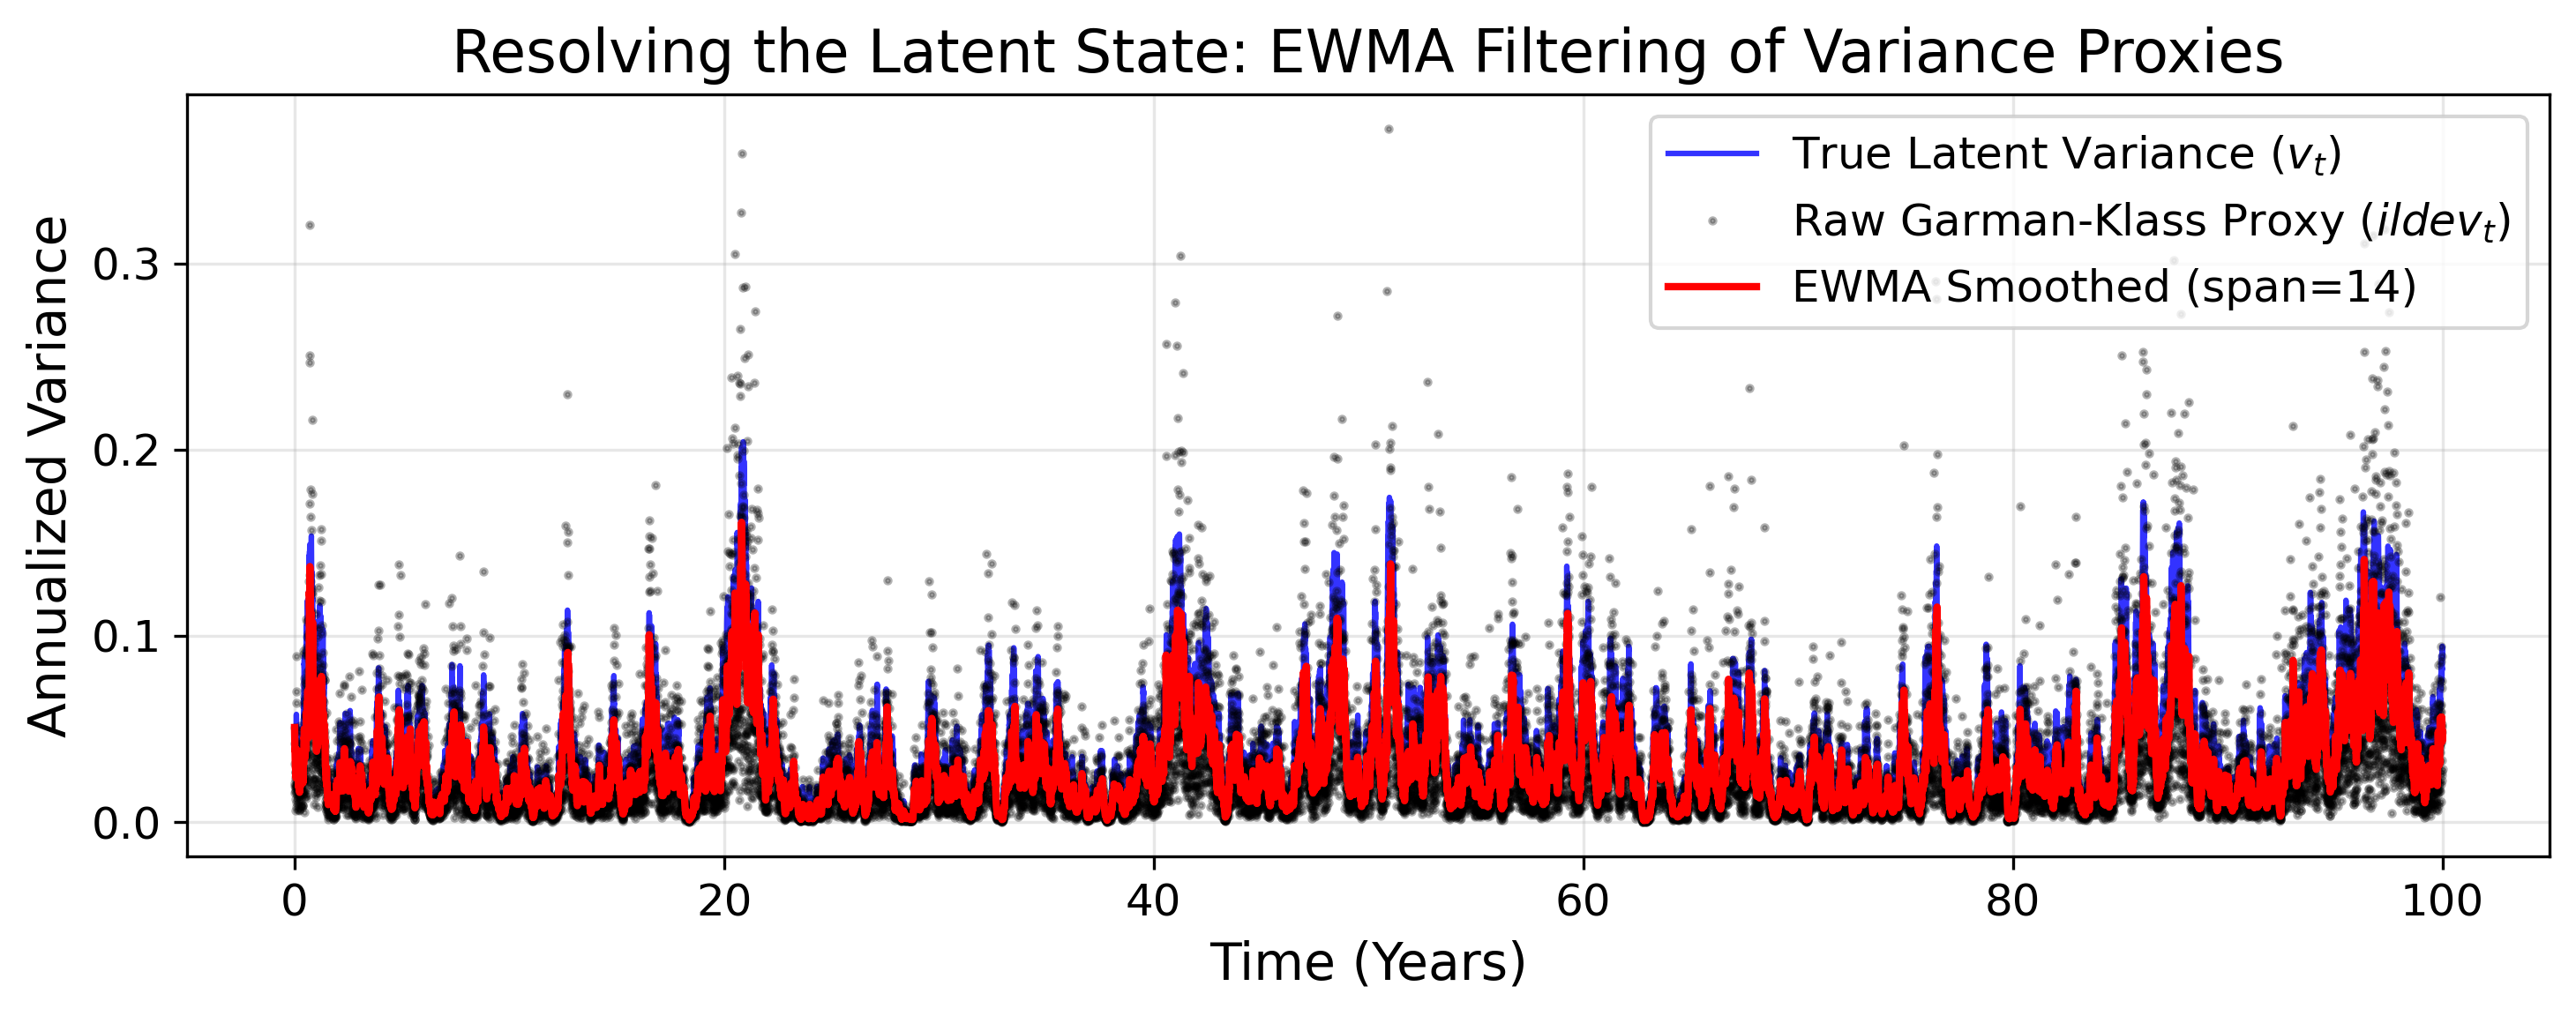

In [ ]:
"""
Empirical Data Pipeline: Garman-Klass Proxy with EWMA Smoothing
Author: Eshwar
ID: pes2ug23cs562
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def apply_ewma_filter(v_proxy, span=10):
    """
    Applies an EWMA filter to smooth high-frequency measurement noise
    from the empirical variance proxy.
    """
    v_series = pd.Series(v_proxy)
    # The span dictates the smoothing window. A span of 10-21 days is
    # typical for monthly/bi-weekly structural volatility memory.
    v_smoothed = v_series.ewm(span=span, adjust=False).mean().values
    return v_smoothed

# Assuming 'v_gk' is the noisy Garman-Klass array generated from your previous simulation
print("Applying EWMA Filter to noisy Garman-Klass proxy...")
span_days = 14
v_smoothed = apply_ewma_filter(v_gk, span=span_days)

# ==========================================
# Visualization: The Smoothing Effect
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))
time_axis = np.arange(len(v_true)) * dt

ax.plot(time_axis, v_true, 'b-', label='True Latent Variance ($v_t$)', alpha=0.8, linewidth=1.5)
ax.plot(time_axis, v_gk, 'k.', label='Raw Garman-Klass Proxy ($\tilde{v}_t$)', alpha=0.3, markersize=3)
ax.plot(time_axis, v_smoothed, 'r-', label=f'EWMA Smoothed (span={span_days})', linewidth=2)

ax.set_title('Resolving the Latent State: EWMA Filtering of Variance Proxies')
ax.set_xlabel('Time (Years)')
ax.set_ylabel('Annualized Variance')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('empirical_ewma_smoothing.pdf', format='pdf', dpi=300)
plt.show()

# You would now pass `v_smoothed` into `build_weak_matrices` instead of `v_gk`
# A, B_v, Q_x, Q_v, Q_xv, centers, Theta, state, h = build_weak_matrices(x, v_smoothed, dt)

Running Noise Ablation Sweep...


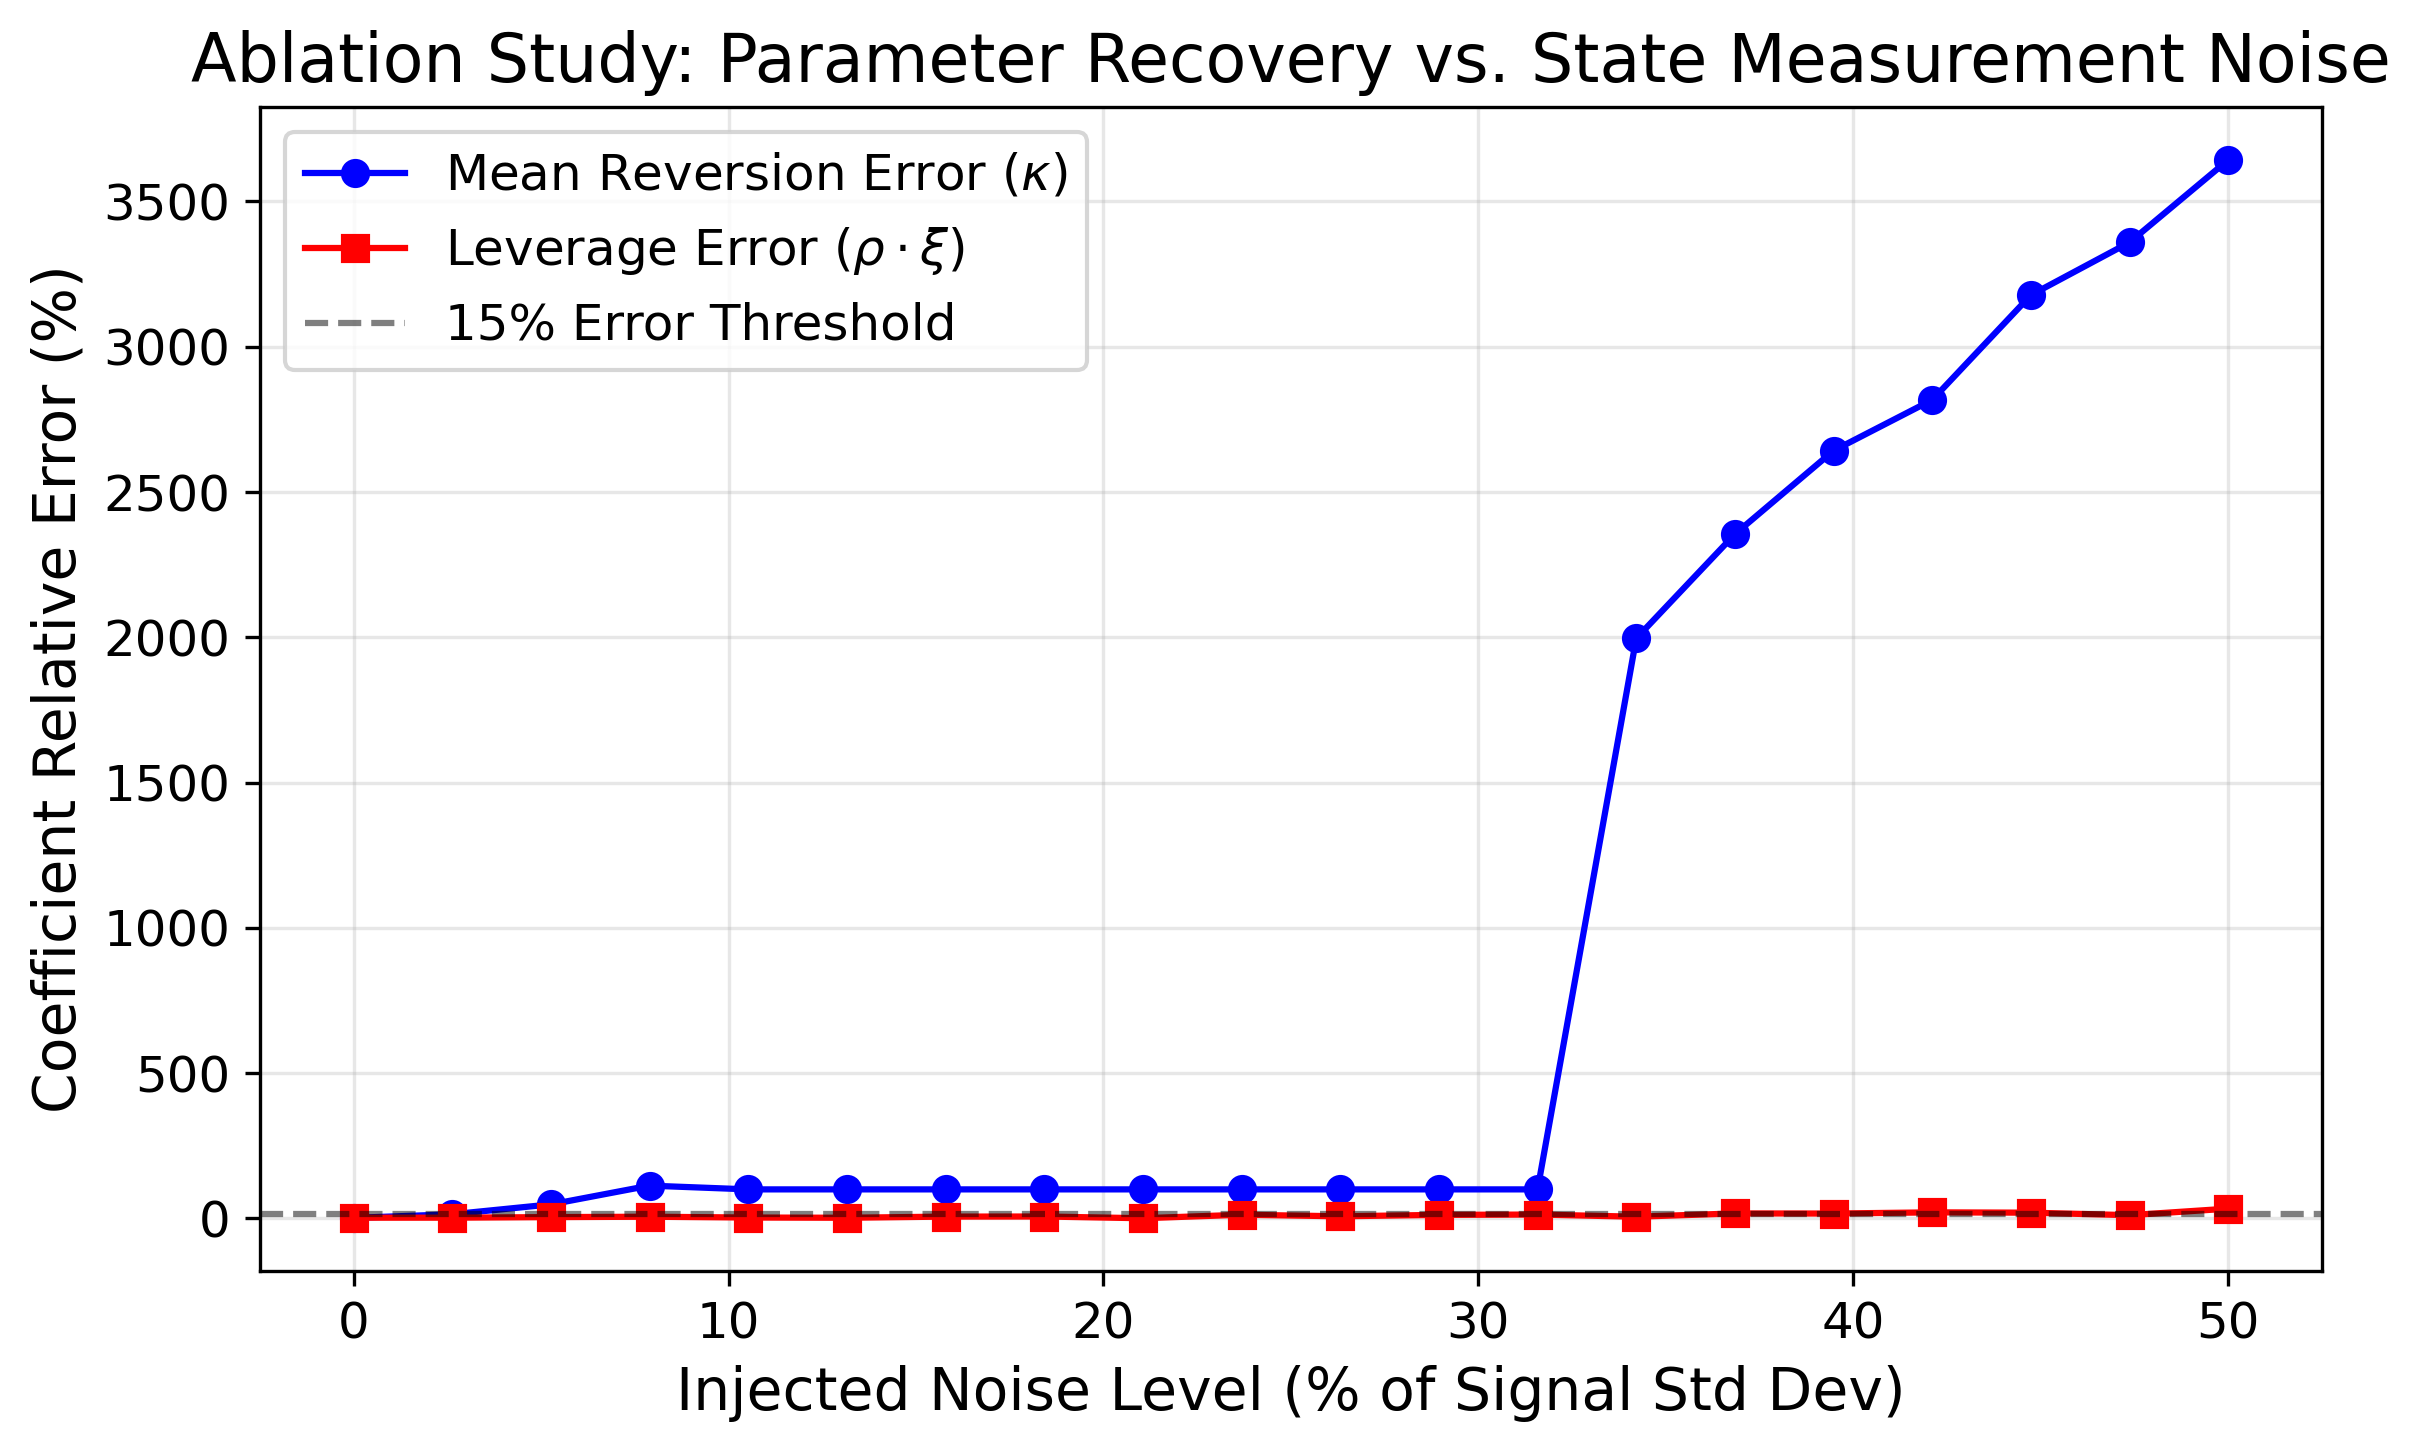

In [ ]:
"""
Robustness Ablation: SINDy Coefficient Error vs. State Noise
Author: Eshwar
ID: pes2ug23cs562
"""
from sklearn.linear_model import LassoCV

def run_noise_ablation_study(x, v_true, dt, noise_levels):
    """
    Sweeps through SNR levels, injecting noise into the true state
    to track the degradation of the Weak SINDy recovery.
    """
    true_kappa = -2.0  # From b_v(v) = kappa*theta - kappa*v
    true_rho_xi = -0.7 * 0.3 # From a_12(v) = rho*xi*v

    error_kappa = []
    error_rho = []

    # Base signal power (standard deviation of the true variance process)
    signal_std = np.std(v_true)

    for noise_std in noise_levels:
        # 1. Inject exact Gaussian noise
        v_corrupted = v_true + np.random.normal(0, noise_std, len(v_true))

        # Ensure strict positivity for Feller condition compliance
        v_corrupted = np.clip(v_corrupted, 1e-6, None)

        # 2. Build Matrices using the corrupted state
        A, B_v, Q_x, Q_v, Q_xv, centers, Theta, state, h = build_weak_matrices(x, v_corrupted, dt)
        A_norms = np.linalg.norm(A, axis=0)
        A_normalized = A / A_norms

        # 3. Recover Mean Reversion (kappa)
        lasso_drift = LassoCV(cv=5, fit_intercept=False)
        lasso_drift.fit(A_normalized, B_v)
        c_hat = lasso_drift.coef_ / A_norms
        recovered_kappa = c_hat[1] # Coefficient of 'v'

        # 4. Recover Leverage (rho * xi)
        lasso_leverage = LassoCV(cv=5, fit_intercept=False)
        lasso_leverage.fit(A_normalized, Q_xv)
        d_hat_xv = lasso_leverage.coef_ / A_norms
        recovered_rho_xi = d_hat_xv[1] # Coefficient of 'v'

        # 5. Calculate Absolute Percentage Errors
        err_k = np.abs((recovered_kappa - true_kappa) / true_kappa) * 100
        err_r = np.abs((recovered_rho_xi - true_rho_xi) / true_rho_xi) * 100

        error_kappa.append(err_k)
        error_rho.append(err_r)

    return error_kappa, error_rho

# ==========================================
# Execute Sweep & Plot
# ==========================================
print("Running Noise Ablation Sweep...")
# Define noise levels as a fraction of the signal standard deviation
noise_fractions = np.linspace(0.0, 0.5, 20)
noise_stds = noise_fractions * np.std(v_true)

err_kappa, err_rho = run_noise_ablation_study(x, v_true, dt, noise_stds)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(noise_fractions * 100, err_kappa, 'b-o', label='Mean Reversion Error ($\kappa$)')
ax.plot(noise_fractions * 100, err_rho, 'r-s', label='Leverage Error ($\\rho\cdot\\xi$)')

# Add a 15% error tolerance threshold line (industry standard for "acceptable" recovery)
ax.axhline(15, color='k', linestyle='--', alpha=0.5, label='15% Error Threshold')

ax.set_title('Ablation Study: Parameter Recovery vs. State Measurement Noise')
ax.set_xlabel('Injected Noise Level (% of Signal Std Dev)')
ax.set_ylabel('Coefficient Relative Error (%)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('noise_ablation_sindy.pdf', format='pdf', dpi=300)
plt.show()

Fetching ^GSPC data from 2007-01-01 to 2010-12-31...
Building Weak-Form Matrices...
Running LASSO Regressions...



=== EXTRACTED EMPIRICAL HESTON PARAMETERS (S&P 500) ===
Mean Reversion Speed (kappa) : 2.3613
Long-term Variance (theta)   : 0.0360 (Implied Vol: 18.96%)
Vol of Vol (xi)              : 0.5301
Leverage Correlation (rho)   : -0.3290



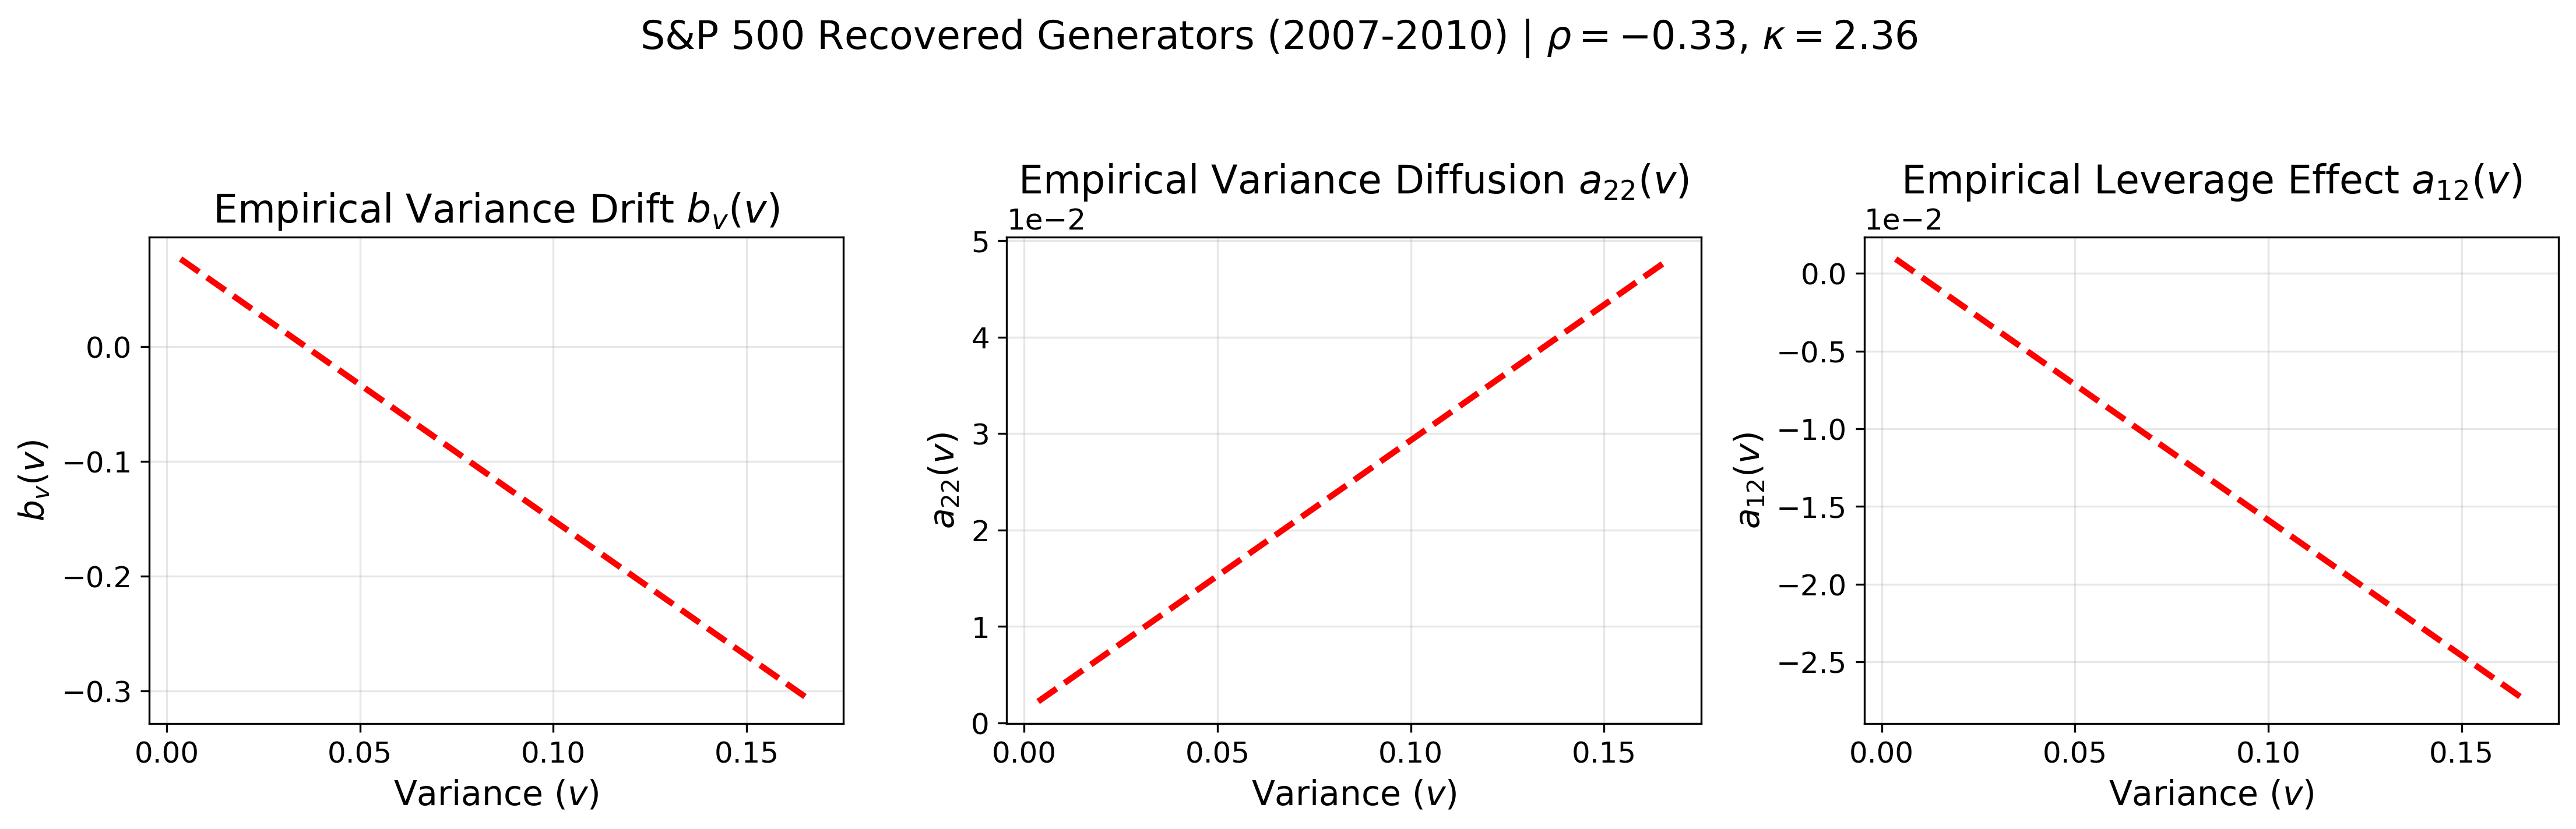

In [ ]:
"""
Phase 4: Empirical Application of Weak Stochastic SINDy
Target: S&P 500 (2007-2010 Financial Crisis)
Author: Eshwar
ID: pes2ug23cs562
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Publication-Ready Plot Settings
# ==========================================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "savefig.bbox": "tight"
})

# ==========================================
# 2. Empirical Data Ingestion & Smoothing
# ==========================================
def fetch_and_prep_empirical_data(ticker='^GSPC', start='2007-01-01', end='2010-12-31'):
    """Fetches OHLC data and computes the EWMA-smoothed Garman-Klass variance."""
    print(f"Fetching {ticker} data from {start} to {end}...")
    df = yf.download(ticker, start=start, end=end, progress=False)

    # Flatten multi-index columns if yfinance returns them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Macro time step (Annualized trading days)
    dt_macro = 1.0 / 252.0

    # Compute log prices
    O = np.log(df['Open'].values)
    H = np.log(df['High'].values)
    L = np.log(df['Low'].values)
    C = np.log(df['Close'].values)

    # Raw Garman-Klass Proxy (Annualized)
    gk_raw = 0.5 * (H - L)**2 - (2*np.log(2) - 1) * (C - O)**2
    v_gk_annualized = np.maximum(gk_raw / dt_macro, 1e-6)

    # EWMA Smoothing (14-day span to filter EIV noise)
    v_series = pd.Series(v_gk_annualized)
    v_smoothed = v_series.ewm(span=14, adjust=False).mean().values

    # Align log-prices with variance (Anchor to Open to prevent forward-leak)
    x_macro = O

    return x_macro, v_smoothed, dt_macro, df.index

# ==========================================
# 3. Weak-Form Matrix Builder (Time-Shifted)
# ==========================================
def build_weak_matrices(x, v_state, dt, M=50, bandwidth_factor=1.5):
    """Builds the design matrix A and response vectors using spatial kernels."""
    # Time-shifted alignment: Use v_{n-1} as the state for step n
    state = v_state[:-1]
    dx = np.diff(x)
    dv = np.diff(v_state)

    Theta = np.vstack([np.ones_like(state), state]).T
    K_features = Theta.shape[1]

    centers = np.linspace(np.percentile(state, 5), np.percentile(state, 95), M)
    h = bandwidth_factor * np.std(state) / np.sqrt(M)

    A = np.zeros((M, K_features))
    B_v = np.zeros(M)
    Q_v = np.zeros(M)
    Q_xv = np.zeros(M)

    for j, center in enumerate(centers):
        K_j = np.exp(-0.5 * ((state - center) / h)**2)
        for k in range(K_features):
            A[j, k] = np.sum(K_j * Theta[:, k]) * dt

        B_v[j] = np.sum(K_j * dv)
        Q_v[j] = np.sum(K_j * dv**2)
        Q_xv[j] = np.sum(K_j * dx * dv)

    return A, B_v, Q_v, Q_xv, centers, Theta, state, h

# ==========================================
# 4. Execution & Parameter Extraction
# ==========================================
x_emp, v_emp, dt, dates = fetch_and_prep_empirical_data()

print("Building Weak-Form Matrices...")
A, B_v, Q_v, Q_xv, centers, Theta, state, h = build_weak_matrices(x_emp, v_emp, dt)

A_norms = np.linalg.norm(A, axis=0)
A_normalized = A / A_norms

print("Running LASSO Regressions...")
# 1. Drift Recovery (Variance)
lasso_drift = LassoCV(cv=5, fit_intercept=False)
lasso_drift.fit(A_normalized, B_v)
c_hat = lasso_drift.coef_ / A_norms
b_hat_v = Theta @ c_hat

# 2. Bias-Corrected Diffusion Recovery (Variance)
Q_v_corr = Q_v - np.array([np.sum(np.exp(-0.5 * ((state - c) / h)**2) * b_hat_v**2) for c in centers]) * dt**2
lasso_diff_v = LassoCV(cv=5, fit_intercept=False)
lasso_diff_v.fit(A_normalized, Q_v_corr)
d_hat_v = lasso_diff_v.coef_ / A_norms

# 3. Leverage Recovery (Cross-variation)
lasso_leverage = LassoCV(cv=5, fit_intercept=False)
lasso_leverage.fit(A_normalized, Q_xv)
d_hat_xv = lasso_leverage.coef_ / A_norms

# --- STRUCTURAL PARAMETER EXTRACTION ---
# b_v(v) = kappa*theta - kappa*v  => c_hat = [kappa*theta, -kappa]
kappa_emp = -c_hat[1]
theta_emp = c_hat[0] / kappa_emp if kappa_emp != 0 else 0

# a_22(v) = xi^2 * v => d_hat_v = [0, xi^2]
xi_emp = np.sqrt(np.maximum(d_hat_v[1], 0))

# a_12(v) = rho * xi * v => d_hat_xv = [0, rho * xi]
rho_emp = d_hat_xv[1] / xi_emp if xi_emp != 0 else 0

print("\n=== EXTRACTED EMPIRICAL HESTON PARAMETERS (S&P 500) ===")
print(f"Mean Reversion Speed (kappa) : {kappa_emp:.4f}")
print(f"Long-term Variance (theta)   : {theta_emp:.4f} (Implied Vol: {np.sqrt(theta_emp)*100:.2f}%)")
print(f"Vol of Vol (xi)              : {xi_emp:.4f}")
print(f"Leverage Correlation (rho)   : {rho_emp:.4f}")
print("=====================================================\n")

# ==========================================
# 5. Publication-Ready Plotting
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
v_plot = np.linspace(np.min(state), np.percentile(state, 95), 100)

est_drift = c_hat[0] + c_hat[1] * v_plot
est_diff_v = d_hat_v[0] + d_hat_v[1] * v_plot
est_leverage = d_hat_xv[0] + d_hat_xv[1] * v_plot

# Plot 1: Empirical Variance Drift
axs[0].plot(v_plot, est_drift, 'r--', linewidth=2.5)
axs[0].set_title('Empirical Variance Drift $b_v(v)$')
axs[0].set_xlabel('Variance ($v$)')
axs[0].set_ylabel('$b_v(v)$')
axs[0].grid(True, alpha=0.3)

# Plot 2: Empirical Variance Diffusion
axs[1].plot(v_plot, est_diff_v, 'r--', linewidth=2.5)
axs[1].set_title('Empirical Variance Diffusion $a_{22}(v)$')
axs[1].set_xlabel('Variance ($v$)')
axs[1].set_ylabel('$a_{22}(v)$')
axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[1].grid(True, alpha=0.3)

# Plot 3: Empirical Leverage Effect
axs[2].plot(v_plot, est_leverage, 'r--', linewidth=2.5)
axs[2].set_title('Empirical Leverage Effect $a_{12}(v)$')
axs[2].set_xlabel('Variance ($v$)')
axs[2].set_ylabel('$a_{12}(v)$')
axs[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axs[2].grid(True, alpha=0.3)

plt.suptitle(f"S&P 500 Recovered Generators (2007-2010) | $\\rho={rho_emp:.2f}$, $\\kappa={kappa_emp:.2f}$", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('empirical_sp500_recovery.pdf', format='pdf', dpi=300)
plt.show()